# Experiment 3.0.4 — L2 width and representation capacity

Analysis-only notebook. Training/evaluation are performed by the Slurm pipeline.

Fixed architecture: `30 -> L1 128 (2,3,4) -> L2 W (2,3,4) -> readout`, with `W in {32,64,128,256}` and no L3. W128 reuses Experiment 3.0.3-B.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('artifacts/experiment_3_0_4_l2_width_representation_capacity/l2_width_v1')
native = pd.read_csv(ROOT / 'experiment_3_0_4_native_summary.csv')
probes = pd.read_csv(ROOT / 'experiment_3_0_4_layer_probe_summary.csv')
diagnostics = pd.read_csv(ROOT / 'experiment_3_0_4_diagnostic_summary.csv')
firing = pd.read_csv(ROOT / 'experiment_3_0_4_firing_rate_summary.csv')


## Native balanced accuracy vs L2 width


,objective,l2_width,mean_test_balanced_accuracy,sd_test_balanced_accuracy,mean_train_test_ba_gap,mean_head_feature_dim,mean_head_parameter_count
0,fixed250_sequence_ce,32,0.506912,0.009881,0.442977,512.0,6156.0
1,fixed250_sequence_ce,64,0.537438,0.050943,0.456940,1024.0,12300.0
2,fixed250_sequence_ce,128,0.497001,0.017805,0.495249,2048.0,24588.0
3,fixed250_sequence_ce,256,0.536656,0.015304,0.449755,4096.0,49164.0
4,relative10_sequence_ce,32,0.710695,0.047301,0.275827,320.0,3852.0
5,relative10_sequence_ce,64,0.684893,0.043805,0.293296,640.0,7692.0
6,relative10_sequence_ce,128,0.676388,0.024585,0.309558,1280.0,15372.0
7,relative10_sequence_ce,256,0.664731,0.005705,0.316900,2560.0,30732.0
8,timestep_ce,32,0.409432,0.013585,0.197109,32.0,396.0
9,timestep_ce,64,0.459936,0.052526,0.249236,64.0,780.0


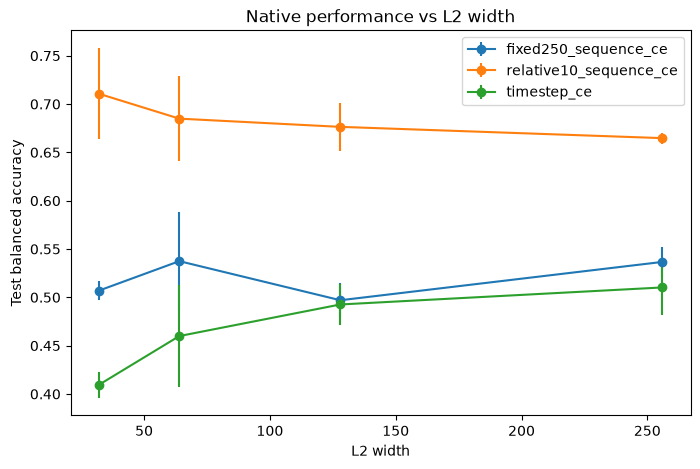

In [2]:
display(native[['objective', 'l2_width', 'mean_test_balanced_accuracy', 'sd_test_balanced_accuracy', 'mean_train_test_ba_gap', 'mean_head_feature_dim', 'mean_head_parameter_count']])

fig, ax = plt.subplots(figsize=(8, 5))
for objective, part in native.groupby('objective'):
    part = part.sort_values('l2_width')
    ax.errorbar(part['l2_width'], part['mean_test_balanced_accuracy'], yerr=part['sd_test_balanced_accuracy'], marker='o', label=objective)
ax.set_xlabel('L2 width')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Native performance vs L2 width')
ax.legend()
plt.show()


## Raw fixed250 vs PCA128 dimension-matched probe

If raw probe BA continues increasing with width but PCA128 saturates, the extra gain is likely associated with the growing downstream feature dimension rather than a more compact discriminative representation.


,objective,l2_width,probe_type,mean_input_feature_dim,mean_feature_dim,mean_probe_test_balanced_accuracy,sd_probe_test_balanced_accuracy
3,fixed250_sequence_ce,32,fixed250,512.0,512.0,0.515151,0.041967
4,fixed250_sequence_ce,32,fixed250_pca128,512.0,128.0,0.470723,0.029361
9,fixed250_sequence_ce,64,fixed250,1024.0,1024.0,0.546621,0.025202
10,fixed250_sequence_ce,64,fixed250_pca128,1024.0,128.0,0.474620,0.038353
15,fixed250_sequence_ce,128,fixed250,2048.0,2048.0,0.494966,0.006235
16,fixed250_sequence_ce,128,fixed250_pca128,2048.0,128.0,0.477298,0.034738
21,fixed250_sequence_ce,256,fixed250,4096.0,4096.0,0.519988,0.018909
22,fixed250_sequence_ce,256,fixed250_pca128,4096.0,128.0,0.459188,0.022804
27,relative10_sequence_ce,32,fixed250,512.0,512.0,0.544390,0.031318
28,relative10_sequence_ce,32,fixed250_pca128,512.0,128.0,0.504761,0.038837


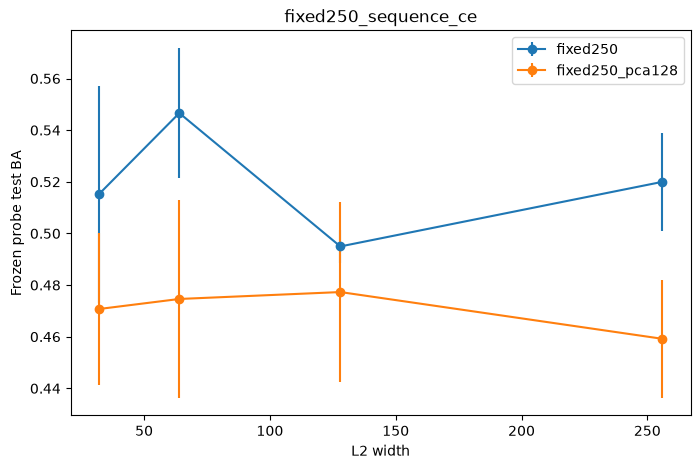

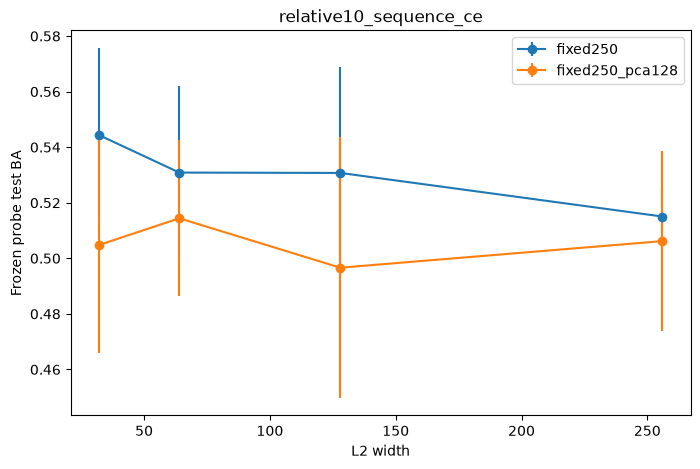

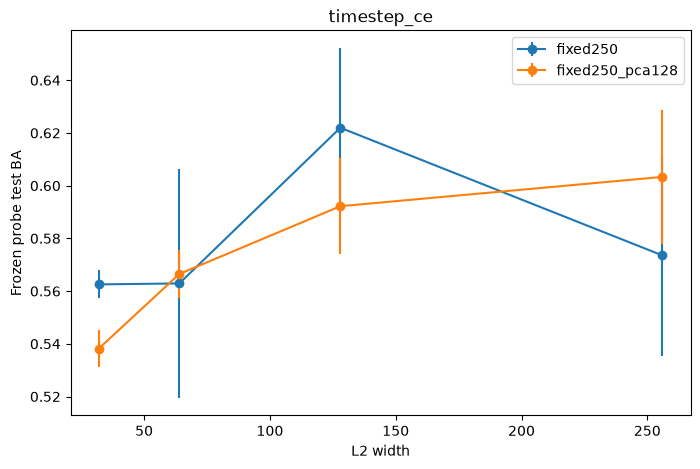

In [3]:
l2 = probes[(probes['layer'] == 'L2') & (probes['probe_type'].isin(['fixed250', 'fixed250_pca128']))].copy()
display(l2[['objective', 'l2_width', 'probe_type', 'mean_input_feature_dim', 'mean_feature_dim', 'mean_probe_test_balanced_accuracy', 'sd_probe_test_balanced_accuracy']])

for objective, part in l2.groupby('objective'):
    fig, ax = plt.subplots(figsize=(8, 5))
    for probe_type, probe_part in part.groupby('probe_type'):
        probe_part = probe_part.sort_values('l2_width')
        ax.errorbar(probe_part['l2_width'], probe_part['mean_probe_test_balanced_accuracy'], yerr=probe_part['sd_probe_test_balanced_accuracy'], marker='o', label=probe_type)
    ax.set_xlabel('L2 width')
    ax.set_ylabel('Frozen probe test BA')
    ax.set_title(objective)
    ax.legend()
    plt.show()


## L1 -> L2 representation gain

The PCA128 gain is the cleaner comparison because both L1 and L2 are projected to the same dimension.


,objective,l2_width,mean_raw_l2_minus_l1_fixed250_probe_ba,mean_pca128_l2_minus_l1_fixed250_probe_ba,mean_l2_raw_minus_pca128_fixed250_probe_ba,mean_l2_pca128_explained_variance_ratio_sum
0,fixed250_sequence_ce,32,0.017054,-0.007080,0.044428,0.972940
1,fixed250_sequence_ce,64,0.032714,-0.021118,0.072001,0.954428
2,fixed250_sequence_ce,128,0.018654,0.023811,0.017669,0.937270
3,fixed250_sequence_ce,256,0.057322,0.012104,0.060800,0.916137
4,relative10_sequence_ce,32,0.014330,0.012769,0.039629,0.971471
5,relative10_sequence_ce,64,0.073906,0.088934,0.016456,0.955853
6,relative10_sequence_ce,128,0.057055,0.038607,0.034115,0.939346
7,relative10_sequence_ce,256,0.043469,0.055527,0.008850,0.922526
8,timestep_ce,32,0.020338,0.054659,0.024370,0.968170
9,timestep_ce,64,0.038931,0.056513,-0.003587,0.947554


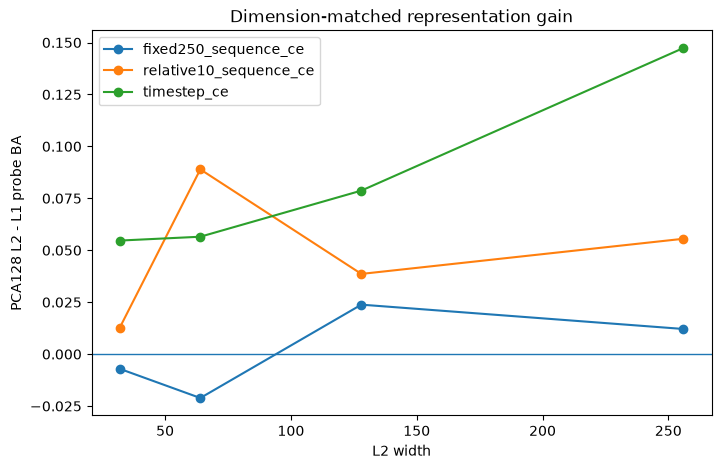

In [4]:
display(diagnostics[['objective', 'l2_width', 'mean_raw_l2_minus_l1_fixed250_probe_ba', 'mean_pca128_l2_minus_l1_fixed250_probe_ba', 'mean_l2_raw_minus_pca128_fixed250_probe_ba', 'mean_l2_pca128_explained_variance_ratio_sum']])

fig, ax = plt.subplots(figsize=(8, 5))
for objective, part in diagnostics.groupby('objective'):
    part = part.sort_values('l2_width')
    ax.plot(part['l2_width'], part['mean_pca128_l2_minus_l1_fixed250_probe_ba'], marker='o', label=objective)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel('L2 width')
ax.set_ylabel('PCA128 L2 - L1 probe BA')
ax.set_title('Dimension-matched representation gain')
ax.legend()
plt.show()


## Activity / cost trade-off


,objective,l2_width,mean_test_balanced_accuracy,mean_l2_test_firing_rate,mean_l2_test_total_spikes_per_timestep
0,fixed250_sequence_ce,32,0.506912,0.257685,8.245913
1,fixed250_sequence_ce,64,0.537438,0.282083,18.053291
2,fixed250_sequence_ce,128,0.497001,0.239800,30.694417
3,fixed250_sequence_ce,256,0.536656,0.150280,38.471642
4,relative10_sequence_ce,32,0.710695,0.304515,9.744478
5,relative10_sequence_ce,64,0.684893,0.255227,16.334521
6,relative10_sequence_ce,128,0.676388,0.227975,29.180749
7,relative10_sequence_ce,256,0.664731,0.172508,44.162138
8,timestep_ce,32,0.409432,0.331999,10.623978
9,timestep_ce,64,0.459936,0.316001,20.224045


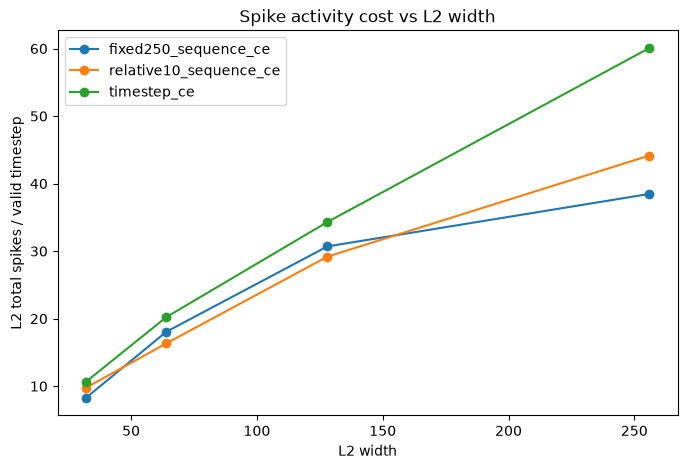

In [5]:
cost = diagnostics[['objective', 'l2_width', 'mean_test_balanced_accuracy', 'mean_l2_test_firing_rate', 'mean_l2_test_total_spikes_per_timestep']].copy()
display(cost)

fig, ax = plt.subplots(figsize=(8, 5))
for objective, part in cost.groupby('objective'):
    part = part.sort_values('l2_width')
    ax.plot(part['l2_width'], part['mean_l2_test_total_spikes_per_timestep'], marker='o', label=objective)
ax.set_xlabel('L2 width')
ax.set_ylabel('L2 total spikes / valid timestep')
ax.set_title('Spike activity cost vs L2 width')
ax.legend()
plt.show()
